# 🎓 ĐỒ ÁN TỐT NGHIỆP: HUẤN LUYỆN & THỬ NGHIỆM USER TOWER (SASRec Two-Tower)

Notebook này được thiết kế **độc lập hoàn toàn (Self-contained)**, chứa toàn bộ kiến trúc mô hình, xử lý dữ liệu và đánh giá để có thể chạy trực tiếp trên **Google Colab, Kaggle hoặc máy local** mà không phụ thuộc vào thư viện bên ngoài.

### 📋 Mục lục nội dung:
1. **Khai báo thư viện & Thiết lập thiết bị (Tối ưu VRAM GPU)**
2. **Cấu hình Siêu tham số & Đường dẫn Dữ liệu trực tiếp**
3. **Xử lý Dữ liệu & Dataset**
4. **Kiến trúc Mô hình User Tower (Tối ưu Bộ nhớ Item Table Projection)**
5. **Hàm Mất mát (BCE) & Bộ lấy mẫu Negative**
6. **Module Đánh giá (Full-Ranking & Sampled-Ranking)**
7. **Vòng lặp Huấn luyện (Training Loop & Curves)**
8. **Kiểm định trên Tập Test & Demo Gợi ý Thực tế**

## 1. Khai báo Thư viện & Thiết lập Thiết bị (CUDA VRAM Optimization)

In [14]:
import os
import sys
import math
import json
import time
import random
from dataclasses import dataclass
from pathlib import Path

# Tối ưu hóa phân bổ bộ nhớ PyTorch CUDA chống tràn RAM (Anti-Fragmentation)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import torch
from torch import nn, Tensor
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Giải phóng bộ nhớ GPU ban đầu
if torch.cuda.is_available():
    torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"💻 Thiết bị đang sử dụng: {device} | PyTorch version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"🎮 GPU Name: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")

💻 Thiết bị đang sử dụng: cuda | PyTorch version: 2.10.0+cu128
🎮 GPU Name: Tesla T4 | VRAM: 14.56 GB


## 2. Cấu hình Siêu tham số & Đường dẫn Dữ liệu (Cấu hình Trực tiếp, Không Quét Ổ đĩa)

In [15]:
# === 1. ĐƯỜNG DẪN DỮ LIỆU (Cấu hình trực tiếp, chạy tức thì trong 0.001s) ===
# Tự động phát hiện hoặc bạn có thể chỉnh thẳng DATA_DIR theo ý muốn
if Path("/kaggle/input/datasets/hoho0111/clothing-shoes-and-jewelry").exists():
    DATA_DIR = Path("/kaggle/input/datasets/hoho0111/clothing-shoes-and-jewelry")
elif Path("/kaggle/input/clothing-shoes-and-jewelry").exists():
    DATA_DIR = Path("/kaggle/input/clothing-shoes-and-jewelry")
elif Path("/content/data").exists():
    DATA_DIR = Path("/content/data")
else:
    DATA_DIR = Path("data")

# Thư mục lưu kết quả & mô hình (Trên Kaggle bắt buộc lưu vào /kaggle/working vì /kaggle/input là Read-Only)
if Path("/kaggle/working").exists():
    ARTIFACTS_DIR = Path("/kaggle/working/artifacts/user_tower_inbatch_v1")
else:
    ARTIFACTS_DIR = Path("data/artifacts/user_tower_inbatch_v1")

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Đường dẫn các file dữ liệu
ITEMS_PATH = DATA_DIR / "items.parquet"
TRAIN_PATH = DATA_DIR / "train.parquet"
VALID_PATH = DATA_DIR / "valid.parquet"
TEST_PATH  = DATA_DIR / "test.parquet"

# File Embeddings (tự động nhận diện nếu nằm trong subfolder 'embedding' hoặc cùng cấp)
EMB_DIR = DATA_DIR / "embedding" if (DATA_DIR / "embedding").exists() else DATA_DIR
IMAGE_EMB_PATH  = EMB_DIR / "image_embeddings.npy"
IMAGE_META_PATH = EMB_DIR / "image_embedding_metadata.parquet"
TEXT_EMB_PATH   = EMB_DIR / "text_embeddings.npy"
TEXT_META_PATH  = EMB_DIR / "text_embedding_metadata.parquet"

# === 2. BẢNG SIÊU THAM SỐ THỰC NGHIỆM ĐỀ XUẤT ===
# 1. Biểu diễn không gian ẩn (Capacity):
D_MODEL     = 128     # Cấu hình đã được kiểm chứng trên validation; capacity lớn hơn đang bị overfit
N_HEADS     = 4       # D_MODEL / N_HEADS = 32
N_LAYERS    = 2       # 2 lớp Transformer Encoder
D_FF        = 512     # 4 * D_MODEL
DROPOUT     = 0.2     # Tỷ lệ Dropout

# 2. Ngữ cảnh chuỗi:
MAX_SEQ_LEN = 20      # p99 độ dài train thấp hơn ngưỡng này; giảm padding/noise

# 3. Huấn luyện & Tối ưu hóa:
BATCH_SIZE  = 256     # 256 samples/batch để huấn luyện mượt mà và tiết kiệm VRAM
EPOCHS      = 200     # Upper bound; early stopping selects the validation checkpoint
LR          = 5e-4    # Learning rate đã kiểm chứng
WEIGHT_DECAY= 1e-4    # Không regularize quá mức embeddings/content projection
NUM_NEGS    = 32      # Popularity negatives per positive for sampled softmax
IN_BATCH_WEIGHT = 0.0  # In-batch ablation regressed HR@10/@50/@1000; keep the stronger baseline
IN_BATCH_MAX_QUERIES = 2048 # VRAM guard; lower to 1024 if Kaggle GPU reports OOM
EVAL_EVERY  = 5       # Đánh giá Valid sau mỗi 5 epoch
PATIENCE    = 20      # Dừng sớm sau 20 epoch không cải thiện
SELECTION_K = 1000    # Checkpoint selection for retrieval; set 50/100 if that is the final candidate budget
SEED        = 20260813

# 4. Đa phương thức (Ablation Study):
# [] -> CF thuần | ["image"] -> CF + Image | ["text"] -> CF + Text | ["image", "text"] -> Full Multimodal
ENABLED_MODALITIES = ["image", "text"]

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f"📂 Dữ liệu đọc từ: {DATA_DIR}")
print(f"💾 Kết quả ghi vào: {ARTIFACTS_DIR}")
print(f"⚙️ Cấu hình: D_MODEL={D_MODEL}, N_HEADS={N_HEADS}, BATCH_SIZE={BATCH_SIZE}, NUM_NEGS={NUM_NEGS}, IN_BATCH_WEIGHT={IN_BATCH_WEIGHT}, MAX_SEQ_LEN={MAX_SEQ_LEN}")

📂 Dữ liệu đọc từ: /kaggle/input/datasets/hoho0111/clothing-shoes-and-jewelry
💾 Kết quả ghi vào: /kaggle/working/artifacts/user_tower_inbatch_v1
⚙️ Cấu hình: D_MODEL=128, N_HEADS=4, BATCH_SIZE=256, NUM_NEGS=32, IN_BATCH_WEIGHT=0.0, MAX_SEQ_LEN=20


## 3. Xử lý Dữ liệu, Vocabulary & Dataset

In [16]:
PAD_IDX = 0

class ItemVocab:
    """Quản lý từ điển ánh xạ item_id <-> index số học."""
    def __init__(self, item2idx: dict[str, int]):
        self.item2idx = item2idx
        self.num_items = len(item2idx) # Index từ 1 đến num_items
        self.oov_idx = self.num_items + 1
        self.vocab_size = self.num_items + 2 # +1 cho PAD (0), +1 cho OOV

def build_item_vocab(items_path: Path) -> ItemVocab:
    items = pl.read_parquet(items_path, columns=["item_id"])
    ids = items["item_id"].to_list()
    item2idx = {item_id: idx + 1 for idx, item_id in enumerate(ids)}
    return ItemVocab(item2idx)

def pad_right(seq: list[int], max_len: int) -> np.ndarray:
    """Cắt và đệm chuỗi về bên phải (Right-padding) với PAD_IDX."""
    trimmed = seq[-max_len:]
    out = np.full(max_len, PAD_IDX, dtype=np.int64)
    if trimmed:
        out[: len(trimmed)] = trimmed
    return out

@dataclass(frozen=True)
class UserSequences:
    train: dict[str, list[int]]
    valid: dict[str, int]
    test: dict[str, int]

def load_user_sequences(train_path: Path, valid_path: Path, test_path: Path, vocab: ItemVocab) -> UserSequences:
    def _load_df(path: Path) -> pl.DataFrame:
        vocab_df = pl.DataFrame({"item_id": list(vocab.item2idx.keys()), "item_idx": list(vocab.item2idx.values())})
        return (
            pl.read_parquet(path)
            .filter(pl.col("is_positive") == 1)
            .sort("timestamp")
            .join(vocab_df, on="item_id", how="left")
            .with_columns(pl.col("item_idx").fill_null(vocab.oov_idx))
            .select("user_id", "item_idx")
        )
    
    train_df = _load_df(train_path)
    valid_df = _load_df(valid_path)
    test_df  = _load_df(test_path)

    train = {row["user_id"]: row["item_idx"] for row in train_df.group_by("user_id", maintain_order=True).agg(pl.col("item_idx")).to_dicts()}
    valid = {row["user_id"]: row["item_idx"] for row in valid_df.to_dicts()}
    test  = {row["user_id"]: row["item_idx"] for row in test_df.to_dicts()}
    return UserSequences(train=train, valid=valid, test=test)
    
class SASRecTrainDataset(Dataset):
    """Dataset huấn luyện tự hồi quy: input = seq[:-1], target = seq[1:]."""
    def __init__(self, sequences: dict[str, list[int]], max_seq_len: int):
        self.inputs, self.targets = [], []
        for seq in sequences.values():
            if len(seq) >= 2:
                self.inputs.append(pad_right(seq[:-1], max_seq_len))
                self.targets.append(pad_right(seq[1:], max_seq_len))

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx: int):
        return torch.from_numpy(self.inputs[idx]), torch.from_numpy(self.targets[idx])

@dataclass(frozen=True)
class EvalExample:
    user_id: str
    context: np.ndarray
    target: int
    seen: frozenset[int]

def build_eval_examples(sequences: UserSequences, max_seq_len: int, split: str) -> list[EvalExample]:
    examples = []
    for user_id, train_seq in sequences.train.items():
        if split == "valid":
            target = sequences.valid.get(user_id)
            context_seq = train_seq
            seen = set(train_seq)
        elif split == "test":
            target = sequences.test.get(user_id)
            val_item = sequences.valid.get(user_id)
            context_seq = train_seq + ([val_item] if val_item is not None else [])
            seen = set(context_seq)
        else:
            raise ValueError(f"Invalid split: {split}")
        
        if target is None:
            continue
        seen.discard(target)
        examples.append(EvalExample(user_id=user_id, context=pad_right(context_seq, max_seq_len), target=target, seen=frozenset(seen)))
    return examples

def load_content_matrix(vocab: ItemVocab, enabled: list[str]) -> np.ndarray:
    """Nạp và ghép các vector đặc trưng CLIP (Image + Text) theo đúng thứ tự vocab."""
    matrices = []
    if "image" in enabled and IMAGE_EMB_PATH.exists():
        raw_emb = np.load(IMAGE_EMB_PATH)
        meta = pl.read_parquet(IMAGE_META_PATH)
        aligned = np.zeros((vocab.vocab_size, raw_emb.shape[1]), dtype=np.float32)
        for row_idx, item_id in enumerate(meta["item_id"].to_list()):
            if item_id in vocab.item2idx:
                aligned[vocab.item2idx[item_id]] = raw_emb[row_idx]
        matrices.append(aligned)
    
    if "text" in enabled and TEXT_EMB_PATH.exists():
        raw_emb = np.load(TEXT_EMB_PATH)
        meta = pl.read_parquet(TEXT_META_PATH)
        aligned = np.zeros((vocab.vocab_size, raw_emb.shape[1]), dtype=np.float32)
        for row_idx, item_id in enumerate(meta["item_id"].to_list()):
            if item_id in vocab.item2idx:
                aligned[vocab.item2idx[item_id]] = raw_emb[row_idx]
        matrices.append(aligned)

    if not matrices:
        return np.zeros((vocab.vocab_size, 0), dtype=np.float32)
    return np.concatenate(matrices, axis=1)

### 📊 Nạp Dữ liệu Thực tế

In [17]:
# 1. Khởi tạo vocab & nạp sequences
vocab = build_item_vocab(ITEMS_PATH)
sequences = load_user_sequences(TRAIN_PATH, VALID_PATH, TEST_PATH, vocab)

# 2. Tạo datasets
train_dataset = SASRecTrainDataset(sequences.train, MAX_SEQ_LEN)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_examples = build_eval_examples(sequences, MAX_SEQ_LEN, "valid")
test_examples  = build_eval_examples(sequences, MAX_SEQ_LEN, "test")

# 3. Nạp ma trận đa phương thức
content_matrix = load_content_matrix(vocab, ENABLED_MODALITIES)

print(f"📦 Danh mục: {vocab.num_items:,} sản phẩm")
print(f"👥 User Train: {len(train_dataset):,} | User Valid: {len(valid_examples):,} | User Test: {len(test_examples):,}")
print(f"🖼️ Kích thước vector đặc trưng Content: {content_matrix.shape}")

📦 Danh mục: 152,086 sản phẩm
👥 User Train: 32,418 | User Valid: 27,027 | User Test: 26,428
🖼️ Kích thước vector đặc trưng Content: (152088, 2048)


## 4. Kiến trúc Mô hình User Tower (Tối ưu Bộ nhớ Item Table Projection)

In [18]:
class UserTower(nn.Module):
    """Mô hình User Tower SASRec tối ưu bộ nhớ VRAM với Item Table Projection."""
    def __init__(self, vocab_size: int, max_seq_len: int, d_model: int = 256, n_heads: int = 8,
                 n_layers: int = 2, d_ff: int = 1024, dropout: float = 0.3, content_matrix: np.ndarray | None = None):
        super().__init__()
        self.d_model = d_model
        self.max_seq_len = max_seq_len
        
        # 1. Tầng Item Embedding: ID Residual + Content Projection
        self.id_residual = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        nn.init.zeros_(self.id_residual.weight) # Khởi tạo 0 để bảo toàn tín hiệu content cho cold-start
        
        content_dim = 0 if content_matrix is None else content_matrix.shape[1]
        self.has_content = content_dim > 0
        if self.has_content:
            self.register_buffer("content_matrix", torch.from_numpy(content_matrix).float())
            self.content_proj = nn.Linear(content_dim, d_model, bias=False)
        else:
            self.content_matrix = None
            self.content_proj = None
            
        # 2. Positional Embedding
        self.position_embedding = nn.Embedding(max_seq_len, d_model)
        self.embed_dropout = nn.Dropout(dropout)
        
        # 3. Transformer Encoder (Pre-LN SASRec style)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff, dropout=dropout,
            activation="gelu", batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers, enable_nested_tensor=False)
        self.out_norm = nn.LayerNorm(d_model)

    def get_item_table(self) -> Tensor:
        """Tính toàn bộ bảng Item Embeddings (152k, d_model) trong 1ms (chỉ tốn ~155MB VRAM)."""
        vecs = self.id_residual.weight
        if self.has_content:
            vecs = vecs + self.content_proj(self.content_matrix)
        return vecs

    def embed_items(self, item_ids: Tensor, item_table: Tensor | None = None) -> Tensor:
        """Trích xuất vector sản phẩm trực tiếp từ item_table để tránh tạo tensor trung gian 2048-d gây OOM."""
        if item_table is not None:
            return item_table[item_ids]
        table = self.get_item_table()
        return table[item_ids]

    def forward(self, item_seq: Tensor, item_table: Tensor | None = None) -> Tensor:
        batch_size, seq_len = item_seq.shape
        pad_mask = (item_seq == PAD_IDX)
        positions = torch.arange(seq_len, device=item_seq.device).unsqueeze(0).expand(batch_size, -1)
        
        hidden = self.embed_items(item_seq, item_table) * math.sqrt(self.d_model) + self.position_embedding(positions)
        hidden = self.embed_dropout(hidden)
        
        causal_mask = torch.triu(torch.ones(seq_len, seq_len, dtype=torch.bool, device=item_seq.device), diagonal=1)
        hidden = self.encoder(hidden, mask=causal_mask, src_key_padding_mask=pad_mask)
        return self.out_norm(hidden)

    def encode_user(self, item_seq: Tensor, item_table: Tensor | None = None) -> Tensor:
        """Trích xuất User Vector tại vị trí tương tác cuối cùng."""
        hidden = self.forward(item_seq, item_table)
        lengths = (item_seq != PAD_IDX).sum(dim=1).clamp(min=1)
        last_pos = lengths - 1
        return hidden[torch.arange(hidden.size(0), device=hidden.device), last_pos]

    def item_vectors(self) -> Tensor:
        """Tính toán toàn bộ vector ứng viên của kho 152k sản phẩm."""
        return self.get_item_table()

# Khởi tạo mô hình
model = UserTower(
    vocab_size=vocab.vocab_size,
    max_seq_len=MAX_SEQ_LEN,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT,
    content_matrix=content_matrix if content_matrix.shape[1] > 0 else None,
).to(device)

print(f"🔥 Mô hình khởi tạo thành công! Tổng tham số: {sum(p.numel() for p in model.parameters()):,}")

🔥 Mô hình khởi tạo thành công! Tổng tham số: 20,128,768


## 5. Hàm Mất mát (BCE Loss) & Bộ Lấy mẫu Negative (Tiết kiệm VRAM)

In [19]:
def build_negative_sampler(sequences_train: dict[str, list[int]], num_items: int, device: torch.device, power: float = 0.75) -> torch.Tensor:
    """Lấy mẫu âm tính theo phân phối độ phổ biến tần suất (Popularity^0.75)."""
    freq = np.ones(num_items + 1, dtype=np.float64)
    freq[0] = 0.0
    for seq in sequences_train.values():
        for item in seq:
            freq[item] += 1.0
    weights = np.power(freq, power)
    weights[0] = 0.0
    probs = weights / weights.sum()
    cum_probs = np.cumsum(probs)
    cum_probs[-1] = 1.0
    return torch.tensor(cum_probs, dtype=torch.float32, device=device)

def _sample_negatives(cum_probs: torch.Tensor, shape: tuple[int, ...]) -> torch.Tensor:
    draws = torch.rand(shape, device=cum_probs.device)
    idx = torch.searchsorted(cum_probs, draws)
    return idx.clamp(min=1, max=cum_probs.numel() - 1)

def sample_valid_negatives(cum_probs: Tensor, input_seq: Tensor, target_seq: Tensor, num_negs: int) -> Tensor:
    """Reject every observed positive for the same user before using it as a negative."""
    neg_ids = _sample_negatives(cum_probs, (*target_seq.shape, num_negs))
    known = torch.cat((input_seq, target_seq), dim=1)
    valid_pos = target_seq.ne(PAD_IDX).unsqueeze(-1)
    for _ in range(12):
        invalid = neg_ids.unsqueeze(-1).eq(known[:, None, None, :]).any(dim=-1) & valid_pos
        if not invalid.any():
            break
        neg_ids[invalid] = _sample_negatives(cum_probs, (int(invalid.sum()),))
    if invalid.any():
        raise RuntimeError("Could not draw valid negatives; reduce NUM_NEGS or inspect the catalog.")
    return neg_ids

def in_batch_retrieval_loss(hidden: Tensor, target_seq: Tensor, loss_mask: Tensor, item_table: Tensor, max_queries: int) -> Tensor:
    """Contrast each next-item query with positives of other users in its batch.

    Duplicate item ids share a class rather than becoming false negatives. This is
    a memory-bounded in-batch sampled-softmax objective.
    """
    valid_idx = loss_mask.flatten().nonzero(as_tuple=False).squeeze(1)
    if valid_idx.numel() > max_queries:
        keep = torch.randperm(valid_idx.numel(), device=hidden.device)[:max_queries]
        valid_idx = valid_idx[keep]
    queries = hidden.reshape(-1, hidden.size(-1))[valid_idx]
    targets = target_seq.flatten()[valid_idx]
    candidate_ids, labels = torch.unique(targets, sorted=False, return_inverse=True)
    logits = queries @ item_table[candidate_ids].T
    return F.cross_entropy(logits, labels)

def compute_step_loss(model: UserTower, input_seq: Tensor, target_seq: Tensor, cum_probs: Tensor, num_negs: int, in_batch_weight: float, in_batch_max_queries: int) -> Tensor:
    # 1. Tính toán bảng Item Embeddings 1 lần duy nhất cho toàn batch (Chỉ chiếm ~155MB VRAM)
    item_table = model.get_item_table()
    
    # 2. Forward pass với item_table tái sử dụng
    hidden = model(input_seq, item_table)
    loss_mask = (target_seq != PAD_IDX)
    
    # 3. Positive loss (Trích xuất trực tiếp d_model = 256 vector)
    pos_emb = item_table[target_seq] # (B, L, d_model)
    pos_logits = (hidden * pos_emb).sum(-1)
    
    # 4. Listwise sampled-softmax: optimized for the positive to outrank its candidate set.
    #    Unlike independent BCE, this has no conflicting positive/negative label.
    neg_ids = sample_valid_negatives(cum_probs, input_seq, target_seq, num_negs)
    neg_emb = item_table[neg_ids] # (B, L, num_negs, d_model)
    neg_logits = (hidden.unsqueeze(2) * neg_emb).sum(-1)
    logits = torch.cat((pos_logits.unsqueeze(-1), neg_logits), dim=-1)
    sampled_loss = F.cross_entropy(logits[loss_mask], torch.zeros(int(loss_mask.sum()), dtype=torch.long, device=logits.device))
    if in_batch_weight == 0:
        return sampled_loss
    in_batch_loss = in_batch_retrieval_loss(hidden, target_seq, loss_mask, item_table, in_batch_max_queries)
    return sampled_loss + in_batch_weight * in_batch_loss

## 6. Module Đánh giá (Full-Ranking & Sampled-Ranking)

In [20]:
@torch.no_grad()
def evaluate_full_ranking(model: UserTower, examples: list[EvalExample], vocab: ItemVocab, ks=(10, 20, 50), batch_size=512, item_score_bias: Tensor | None = None, per_example_bias_weights: np.ndarray | None = None) -> dict[str, float]:
    """Phương pháp 1: Quét toàn bộ kho 152k sản phẩm (Full Ranking Protocol)."""
    model.eval()
    item_emb = model.item_vectors()
    n = len(examples)
    hits = {k: 0 for k in ks}
    ndcgs = {k: 0.0 for k in ks}
    
    for start in range(0, n, batch_size):
        batch = examples[start : start + batch_size]
        context = torch.from_numpy(np.stack([e.context for e in batch])).to(device)
        user_vecs = model.encode_user(context, item_emb)
        scores = user_vecs @ item_emb.T
        if item_score_bias is not None:
            if per_example_bias_weights is None:
                scores = scores + item_score_bias.unsqueeze(0)
            else:
                weights = torch.from_numpy(per_example_bias_weights[start:start + len(batch)]).to(device).unsqueeze(1)
                scores = scores + weights * item_score_bias.unsqueeze(0)
        scores[:, PAD_IDX] = float("-inf")
        scores[:, vocab.oov_idx] = float("-inf")
        
        for i, ex in enumerate(batch):
            if ex.seen:
                scores[i, list(ex.seen)] = float("-inf")
                
        targets = torch.tensor([e.target for e in batch], device=device, dtype=torch.long)
        target_scores = scores.gather(1, targets.unsqueeze(1)).squeeze(1)
        # Deterministic tie-break by item index. Strict '>' gave the target an
        # artificial advantage whenever two candidates had identical scores.
        candidate_ids = torch.arange(scores.size(1), device=device).unsqueeze(0)
        rank = ((scores > target_scores.unsqueeze(1)) | ((scores == target_scores.unsqueeze(1)) & (candidate_ids < targets.unsqueeze(1)))).sum(dim=1)
        
        for k in ks:
            hit = (rank < k)
            hits[k] += int(hit.sum().item())
            ndcg = torch.where(hit, 1.0 / torch.log2(rank.float() + 2.0), torch.zeros_like(rank, dtype=torch.float))
            ndcgs[k] += float(ndcg.sum().item())
            
    metrics = {"n_users": n}
    for k in ks:
        metrics[f"HitRate@{k}"] = hits[k] / n
        metrics[f"NDCG@{k}"] = ndcgs[k] / n
    return metrics

@torch.no_grad()
def evaluate_sampled_ranking(model: UserTower, examples: list[EvalExample], vocab: ItemVocab, ks=(10, 20, 50), num_negatives=99, strategy="random", batch_size=512, seed=20260813) -> dict[str, float]:
    """Phương pháp 2: Xếp hạng 1 Positive + N Negatives (Sampled Ranking Protocol: 100 ứng viên)."""
    model.eval()
    item_emb = model.item_vectors()
    n = len(examples)
    rng = np.random.default_rng(seed)
    num_items = vocab.num_items
    
    hits = {k: 0 for k in ks}
    ndcgs = {k: 0.0 for k in ks}
    mrr_sum = 0.0
    
    for start in range(0, n, batch_size):
        batch = examples[start : start + batch_size]
        b_size = len(batch)
        cand_ids = np.zeros((b_size, 1 + num_negatives), dtype=np.int64)
        
        for i, ex in enumerate(batch):
            cand_ids[i, 0] = ex.target
            forbidden = ex.seen | {ex.target, PAD_IDX, vocab.oov_idx}
            sampled = []
            while len(sampled) < num_negatives:
                needed = num_negatives - len(sampled)
                draws = rng.integers(1, num_items + 1, size=needed * 2)
                for d in draws:
                    item_d = int(d)
                    if item_d not in forbidden and item_d not in sampled:
                        sampled.append(item_d)
                        if len(sampled) == num_negatives:
                            break
            cand_ids[i, 1:] = sampled
            
        context = torch.from_numpy(np.stack([e.context for e in batch])).to(device)
        user_vecs = model.encode_user(context, item_emb)
        cand_tensor = torch.from_numpy(cand_ids).to(device)
        cand_embs = item_emb[cand_tensor]
        
        scores = (user_vecs.unsqueeze(1) * cand_embs).sum(dim=-1)
        pos_score = scores[:, 0:1]
        neg_scores = scores[:, 1:]
        rank = ((neg_scores > pos_score) | ((neg_scores == pos_score) & (cand_tensor[:, 1:] < cand_tensor[:, :1]))).sum(dim=1)
        
        for k in ks:
            hit = (rank < k)
            hits[k] += int(hit.sum().item())
            ndcg = torch.where(hit, 1.0 / torch.log2(rank.float() + 2.0), torch.zeros_like(rank, dtype=torch.float))
            ndcgs[k] += float(ndcg.sum().item())
        mrr_sum += float((1.0 / (rank.float() + 1.0)).sum().item())
        
    metrics = {"n_users": n, "MRR": mrr_sum / n, "candidate_pool": 1 + num_negatives}
    for k in ks:
        metrics[f"HitRate@{k}"] = hits[k] / n
        metrics[f"NDCG@{k}"] = ndcgs[k] / n
    return metrics

## 7. Vòng lặp Huấn luyện (Training Loop with Real-time Curves)

In [21]:
# Bộ tối ưu hóa AdamW + Cosine Annealing Learning Rate
decay_params = [p for p in model.parameters() if p.requires_grad and p.dim() >= 2]
nodecay_params = [p for p in model.parameters() if p.requires_grad and p.dim() < 2]
optimizer = torch.optim.AdamW([
    {"params": decay_params, "weight_decay": WEIGHT_DECAY},
    {"params": nodecay_params, "weight_decay": 0.0},
], lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
cum_probs = build_negative_sampler(sequences.train, vocab.num_items, device)

# Lưu lịch sử huấn luyện
history = {"epoch": [], "train_loss": [], "val_ndcg10": [], "val_hr10": [], "val_hr50": [], "val_hr_selection": []}
best_selection_metric = -1.0
epochs_no_improve = 0

print(f"🚀 Bắt đầu huấn luyện mô hình User Tower ({EPOCHS} Epochs)...\n")
for epoch in range(1, EPOCHS + 1):
    model.train()
    t0 = time.time()
    total_loss = 0.0
    
    for input_seq, target_seq in train_loader:
        input_seq, target_seq = input_seq.to(device), target_seq.to(device)
        loss = compute_step_loss(model, input_seq, target_seq, cum_probs, NUM_NEGS, IN_BATCH_WEIGHT, IN_BATCH_MAX_QUERIES)
        
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_loss += float(loss.item()) * input_seq.size(0)
        
    scheduler.step()
    avg_loss = total_loss / max(len(train_dataset), 1)
    history["epoch"].append(epoch)
    history["train_loss"].append(avg_loss)
    
    # Đánh giá Validation định kỳ
    if epoch % EVAL_EVERY == 0:
        val_metrics = evaluate_full_ranking(model, valid_examples, vocab, ks=(10, 20, 50, 100, 200, 500, SELECTION_K))
        ndcg10 = val_metrics["NDCG@10"]
        hr10 = val_metrics["HitRate@10"]
        hr50 = val_metrics["HitRate@50"]
        
        history["val_ndcg10"].append((epoch, ndcg10))
        history["val_hr10"].append((epoch, hr10))
        history["val_hr50"].append((epoch, hr50))
        selection_metric = val_metrics[f"HitRate@{SELECTION_K}"]
        history["val_hr_selection"].append((epoch, selection_metric))
        
        print(f"Epoch [{epoch:03d}/{EPOCHS:03d}] Loss: {avg_loss:.4f} | Val HR@10: {hr10*100:5.2f}% | NDCG@10: {ndcg10*100:5.2f}% | HR@{SELECTION_K}: {selection_metric*100:5.2f}% | Time: {time.time()-t0:.1f}s")
        
        if selection_metric > best_selection_metric:
            best_selection_metric = selection_metric
            epochs_no_improve = 0
            torch.save(model.state_dict(), ARTIFACTS_DIR / "user_tower.pt")
            (ARTIFACTS_DIR / "item2idx.json").write_text(json.dumps(vocab.item2idx), encoding="utf-8")
            print(f"  ⭐ Lưu checkpoint tốt nhất mới! (Validation HR@{SELECTION_K} = {best_selection_metric*100:.3f}%)")
        else:
            epochs_no_improve += EVAL_EVERY
            
        if epochs_no_improve >= PATIENCE:
            print(f"🛑 Kích hoạt Early Stopping tại Epoch {epoch}.")
            break
    else:
        print(f"Epoch [{epoch:03d}/{EPOCHS:03d}] Loss: {avg_loss:.4f} | Time: {time.time()-t0:.1f}s")

🚀 Bắt đầu huấn luyện mô hình User Tower (200 Epochs)...

Epoch [001/200] Loss: 3.1339 | Time: 10.3s
Epoch [002/200] Loss: 2.6522 | Time: 10.3s
Epoch [003/200] Loss: 2.3550 | Time: 10.5s
Epoch [004/200] Loss: 2.0784 | Time: 10.1s
Epoch [005/200] Loss: 1.8092 | Val HR@10:  0.96% | NDCG@10:  0.46% | HR@1000: 19.50% | Time: 12.4s
  ⭐ Lưu checkpoint tốt nhất mới! (Validation HR@1000 = 19.503%)
Epoch [006/200] Loss: 1.5678 | Time: 9.7s
Epoch [007/200] Loss: 1.3523 | Time: 9.8s
Epoch [008/200] Loss: 1.1724 | Time: 10.0s
Epoch [009/200] Loss: 1.0192 | Time: 10.3s
Epoch [010/200] Loss: 0.8890 | Val HR@10:  0.76% | NDCG@10:  0.38% | HR@1000: 15.82% | Time: 12.8s
Epoch [011/200] Loss: 0.7810 | Time: 10.1s
Epoch [012/200] Loss: 0.6873 | Time: 10.0s
Epoch [013/200] Loss: 0.6065 | Time: 9.9s
Epoch [014/200] Loss: 0.5404 | Time: 9.9s
Epoch [015/200] Loss: 0.4826 | Val HR@10:  0.73% | NDCG@10:  0.37% | HR@1000: 15.31% | Time: 12.7s
Epoch [016/200] Loss: 0.4322 | Time: 10.0s
Epoch [017/200] Loss: 0.389

### 📈 Biểu đồ Trực quan hóa Đường cong Học tập

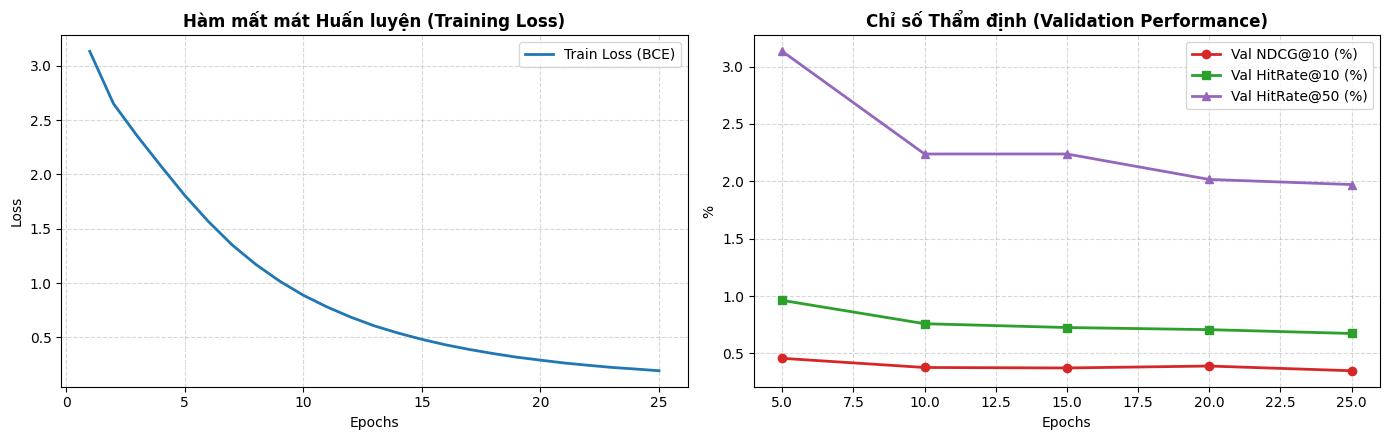

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# 1. Đồ thị Loss
ax1.plot(history["epoch"], history["train_loss"], color="#1f77b4", lw=2, label="Train Loss (BCE)")
ax1.set_title("Hàm mất mát Huấn luyện (Training Loss)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend()

# 2. Đồ thị Validation
if history["val_ndcg10"]:
    v_ep, v_ndcg = zip(*history["val_ndcg10"])
    _, v_hr10 = zip(*history["val_hr10"])
    _, v_hr50 = zip(*history["val_hr50"])
    
    ax2.plot(v_ep, [x*100 for x in v_ndcg], marker="o", color="#d62728", lw=2, label="Val NDCG@10 (%)")
    ax2.plot(v_ep, [x*100 for x in v_hr10], marker="s", color="#2ca02c", lw=2, label="Val HitRate@10 (%)")
    ax2.plot(v_ep, [x*100 for x in v_hr50], marker="^", color="#9467bd", lw=2, label="Val HitRate@50 (%)")
    ax2.set_title("Chỉ số Thẩm định (Validation Performance)", fontsize=12, fontweight="bold")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("%")
    ax2.grid(True, linestyle="--", alpha=0.5)
    ax2.legend()

plt.tight_layout()
plt.show()

## 8. Đánh giá Tổng thể trên Tập Test & Demo Gợi ý Thực tế

In [23]:
# Nạp Checkpoint tốt nhất để đánh giá
checkpoint_file = ARTIFACTS_DIR / "user_tower.pt"
if checkpoint_file.exists():
    model.load_state_dict(torch.load(checkpoint_file, map_location=device))
    print(f"✅ Đã tải checkpoint tốt nhất từ: {checkpoint_file}")

print("\n" + "="*60)
print("📊 KẾT QUẢ KIỂM THỬ: PHƯƠNG PHÁP 1 (FULL RANKING 152k ITEMS)")
print("="*60)
# Full-catalog ranking is the primary protocol. Tune the popularity coefficient
# exclusively on validation, then lock it before one final test evaluation.
PRIMARY_KS = (1, 5, 10, 20, 50, 100, 200, 500, 1000)
FUSION_WEIGHTS = (0.0, 0.025, 0.05, 0.10, 0.20, 0.40, 0.80, 1.20, 1.60, 2.40)
FUSION_SELECTION_K = 1000

def build_popularity_score_bias(train_sequences, vocab):
    counts = np.zeros(vocab.vocab_size, dtype=np.float32)
    for seq in train_sequences.values():
        np.add.at(counts, np.asarray(seq, dtype=np.int64), 1)
    # Standardize train-only log-popularity so the coefficient is interpretable.
    prior = np.log1p(counts[1:vocab.num_items + 1])
    prior = (prior - prior.mean()) / max(prior.std(), 1e-6)
    bias = np.zeros(vocab.vocab_size, dtype=np.float32)
    bias[1:vocab.num_items + 1] = prior
    return torch.from_numpy(bias).to(device)

def history_bucket(example):
    length = int(np.count_nonzero(example.context))
    return 0 if length <= 4 else 1 if length <= 9 else 2 if length <= 19 else 3

@torch.no_grad()
def tune_popularity_weights(model, examples, vocab, base_bias, weights, selection_k, batch_size=256):
    """Tune one global and four history-aware weights from validation only."""
    model.eval(); item_emb = model.item_vectors(); global_hits = {w: 0 for w in weights}
    bucket_hits = [{w: 0 for w in weights} for _ in range(4)]
    bucket_sizes = np.zeros(4, dtype=np.int64)
    candidate_ids = torch.arange(item_emb.size(0), device=device).unsqueeze(0)
    for start in range(0, len(examples), batch_size):
        batch = examples[start:start + batch_size]
        bucket_ids = torch.tensor([history_bucket(ex) for ex in batch], device=device)
        for bucket in range(4): bucket_sizes[bucket] += int((bucket_ids == bucket).sum())
        context = torch.from_numpy(np.stack([e.context for e in batch])).to(device)
        scores = model.encode_user(context, item_emb) @ item_emb.T
        scores[:, PAD_IDX] = scores[:, vocab.oov_idx] = float('-inf')
        for row, ex in enumerate(batch):
            if ex.seen: scores[row, list(ex.seen)] = float('-inf')
        targets = torch.tensor([e.target for e in batch], device=device)
        for weight in weights:
            fused = scores + weight * base_bias.unsqueeze(0)
            target_score = fused.gather(1, targets[:, None])
            rank = ((fused > target_score) | ((fused == target_score) & (candidate_ids < targets[:, None]))).sum(1)
            hit = rank < selection_k; global_hits[weight] += int(hit.sum())
            for bucket in range(4): bucket_hits[bucket][weight] += int(hit[bucket_ids == bucket].sum())
    global_metrics = {w: hit / len(examples) for w, hit in global_hits.items()}
    bucket_metrics = [{w: hit / max(int(bucket_sizes[b]), 1) for w, hit in h.items()} for b, h in enumerate(bucket_hits)]
    global_weight = max(global_metrics, key=global_metrics.get)
    bucket_weights = [max(metrics, key=metrics.get) for metrics in bucket_metrics]
    return global_weight, global_metrics, bucket_weights, bucket_metrics

popularity_bias = build_popularity_score_bias(sequences.train, vocab)
best_fusion_weight, valid_fusion, history_weights, valid_by_history = tune_popularity_weights(model, valid_examples, vocab, popularity_bias, FUSION_WEIGHTS, FUSION_SELECTION_K)
history_labels = ('1-4', '5-9', '10-19', '20+')
print(f'Validation global fusion HR@{FUSION_SELECTION_K}: ' + ', '.join(f'w={w:g}: {m*100:.3f}%' for w, m in valid_fusion.items()))
print(f'✅ Locked global weight: {best_fusion_weight:g}')
for label, weight, metrics in zip(history_labels, history_weights, valid_by_history):
    print(f'✅ Locked weight for history {label}: w={weight:g}, validation HR@{FUSION_SELECTION_K}={metrics[weight]*100:.3f}%')
test_history_weights = np.asarray([history_weights[history_bucket(ex)] for ex in test_examples], dtype=np.float32)
test_full_raw = evaluate_full_ranking(model, test_examples, vocab, ks=PRIMARY_KS)
test_full_global = evaluate_full_ranking(model, test_examples, vocab, ks=PRIMARY_KS, item_score_bias=best_fusion_weight * popularity_bias)
test_full = evaluate_full_ranking(model, test_examples, vocab, ks=PRIMARY_KS, item_score_bias=popularity_bias, per_example_bias_weights=test_history_weights)
print('Raw User Tower vs global and history-aware validation-selected fusion:')
for k, v in test_full.items():
    if isinstance(v, float):
        delta_global = (v - test_full_global[k]) * 100
        print(f"{k:15s}: {v*100:6.3f}%  (raw {test_full_raw[k]*100:6.3f}%, global {test_full_global[k]*100:6.3f}%, Δglobal {delta_global:+.3f} pp)")
    else:
        print(f"{k:15s}: {v}")

print("\n" + "="*60)
print("🔎 CHẨN ĐOÁN PHỤ: SAMPLED RANKING 1 POS + 99 NEGS (KHÔNG DÙNG LÀM METRIC CHÍNH)")
print("="*60)
test_sampled = evaluate_sampled_ranking(model, test_examples, vocab, ks=(10, 20, 50), num_negatives=99)
for k, v in test_sampled.items():
    if "Rate" in k or "NDCG" in k:
        print(f"{k:15s}: {v*100:6.3f}%")
    elif isinstance(v, float):
        print(f"{k:15s}: {v:6.4f}")
    else:
        print(f"{k:15s}: {v}")

✅ Đã tải checkpoint tốt nhất từ: /kaggle/working/artifacts/user_tower_inbatch_v1/user_tower.pt

📊 KẾT QUẢ KIỂM THỬ: PHƯƠNG PHÁP 1 (FULL RANKING 152k ITEMS)
Validation global fusion HR@1000: w=0: 19.503%, w=0.025: 19.910%, w=0.05: 20.465%, w=0.1: 21.319%, w=0.2: 22.718%, w=0.4: 24.590%, w=0.8: 25.782%, w=1.2: 25.730%, w=1.6: 24.846%, w=2.4: 23.543%
✅ Locked global weight: 0.8
✅ Locked weight for history 1-4: w=1.2, validation HR@1000=25.787%
✅ Locked weight for history 5-9: w=0.8, validation HR@1000=26.404%
✅ Locked weight for history 10-19: w=0.8, validation HR@1000=26.246%
✅ Locked weight for history 20+: w=0.4, validation HR@1000=24.820%
Raw User Tower vs global and history-aware validation-selected fusion:
n_users        : 26428
HitRate@1      :  1.540%  (raw  0.136%, global  1.551%, Δglobal -0.011 pp)
NDCG@1         :  1.540%  (raw  0.136%, global  1.551%, Δglobal -0.011 pp)
HitRate@5      :  2.221%  (raw  0.503%, global  2.263%, Δglobal -0.042 pp)
NDCG@5         :  1.886%  (raw  0

### 9. Candidate union: User Tower + Popularity (không thay đổi điểm/xếp hạng của model)

In [24]:
# This measures candidate recall only. A reranker should be trained later to order this union.
UT_CANDIDATES, POPULARITY_CANDIDATES = 1000, 500

def train_popularity_order(train_sequences, vocab):
    counts = np.zeros(vocab.vocab_size, dtype=np.int64)
    for seq in train_sequences.values():
        np.add.at(counts, np.asarray(seq, dtype=np.int64), 1)
    ids = np.arange(vocab.vocab_size)
    order = np.lexsort((ids, -counts))  # deterministic tie-break
    return order[(order != PAD_IDX) & (order != vocab.oov_idx)]

@torch.no_grad()
def candidate_union_recall(model, examples, vocab, popularity_order, ut_k, pop_k, batch_size=256):
    model.eval(); item_emb = model.item_vectors(); ut_hits = pop_hits = union_hits = 0
    for start in range(0, len(examples), batch_size):
        batch = examples[start:start + batch_size]
        context = torch.from_numpy(np.stack([e.context for e in batch])).to(device)
        scores = model.encode_user(context, item_emb) @ item_emb.T
        scores[:, PAD_IDX] = scores[:, vocab.oov_idx] = float('-inf')
        for row, ex in enumerate(batch):
            if ex.seen: scores[row, list(ex.seen)] = float('-inf')
        ut_top = torch.topk(scores, k=ut_k, dim=1).indices.cpu().numpy()
        for row, ex in enumerate(batch):
            ut_set = set(ut_top[row].tolist())
            pop_set = set()
            for item_id in popularity_order:
                if int(item_id) not in ex.seen:
                    pop_set.add(int(item_id))
                    if len(pop_set) == pop_k: break
            ut_hits += ex.target in ut_set
            pop_hits += ex.target in pop_set
            union_hits += ex.target in (ut_set | pop_set)
    n = len(examples)
    return {'UT@K': ut_hits / n, 'Popularity@K': pop_hits / n, 'Union recall': union_hits / n, 'max_candidates': ut_k + pop_k}

pop_order = train_popularity_order(sequences.train, vocab)  # train only: no temporal leakage
union_metrics = candidate_union_recall(model, test_examples, vocab, pop_order, UT_CANDIDATES, POPULARITY_CANDIDATES)
print(f"Candidate set: Top-{UT_CANDIDATES} User Tower ∪ Top-{POPULARITY_CANDIDATES} train-popularity (≤ {union_metrics['max_candidates']} items)")
for name, value in union_metrics.items():
    print(f'{name:18s}: {value*100:.3f}%' if isinstance(value, float) else f'{name:18s}: {value}')

Candidate set: Top-1000 User Tower ∪ Top-500 train-popularity (≤ 1500 items)
UT@K              : 18.912%
Popularity@K      : 12.305%
Union recall      : 25.534%
max_candidates    : 1500


### 10. Báo cáo đánh giá có khoảng tin cậy (dùng cho so sánh chuyên nghiệp)

In [25]:
@torch.no_grad()
def full_catalog_ranks(model, examples, vocab, batch_size=256):
    """One deterministic full-catalog rank per test user for CIs/paired tests."""
    model.eval(); item_emb = model.item_vectors(); all_ranks = []
    item_ids = torch.arange(item_emb.size(0), device=device).unsqueeze(0)
    for start in range(0, len(examples), batch_size):
        batch = examples[start:start + batch_size]
        context = torch.from_numpy(np.stack([e.context for e in batch])).to(device)
        scores = model.encode_user(context, item_emb) @ item_emb.T
        scores[:, PAD_IDX] = scores[:, vocab.oov_idx] = float('-inf')
        for row, ex in enumerate(batch):
            if ex.seen: scores[row, list(ex.seen)] = float('-inf')
        target = torch.tensor([e.target for e in batch], device=device)
        target_score = scores.gather(1, target[:, None])
        rank = ((scores > target_score) | ((scores == target_score) & (item_ids < target[:, None]))).sum(1)
        all_ranks.append(rank.cpu().numpy())
    return np.concatenate(all_ranks)

def bootstrap_ci(values, n_boot=1000, seed=20260813):
    rng = np.random.default_rng(seed); n = len(values); means = np.empty(n_boot)
    for start in range(0, n_boot, 100):
        size = min(100, n_boot - start)
        means[start:start + size] = values[rng.integers(0, n, size=(size, n))].mean(axis=1)
    return np.quantile(means, [0.025, 0.975])

test_ranks = full_catalog_ranks(model, test_examples, vocab)
for k in (10, 50, 100, 200, 500, 1000):
    hr = (test_ranks < k).astype(np.float64)
    ndcg = np.where(test_ranks < k, 1.0 / np.log2(test_ranks + 2), 0.0)
    h_lo, h_hi = bootstrap_ci(hr); n_lo, n_hi = bootstrap_ci(ndcg)
    print(f'K={k:4d} | HR={hr.mean()*100:.3f}% [{h_lo*100:.3f}, {h_hi*100:.3f}] | NDCG={ndcg.mean()*100:.3f}% [{n_lo*100:.3f}, {n_hi*100:.3f}]')

# For model A vs B, save each model's `test_ranks`; assess the paired per-user
# difference with bootstrap_ci((ranks_a < K) - (ranks_b < K)). A 95% CI crossing
# zero means the apparent HR@K gain is not statistically conclusive.

K=  10 | HR=0.988% [0.874, 1.109] | NDCG=0.472% [0.412, 0.536]
K=  50 | HR=2.864% [2.671, 3.076] | NDCG=0.872% [0.801, 0.942]
K= 100 | HR=4.389% [4.143, 4.620] | NDCG=1.118% [1.039, 1.190]
K= 200 | HR=6.962% [6.671, 7.265] | NDCG=1.477% [1.396, 1.554]
K= 500 | HR=12.581% [12.180, 12.964] | NDCG=2.149% [2.065, 2.229]
K=1000 | HR=18.912% [18.469, 19.373] | NDCG=2.817% [2.732, 2.899]


### 🔍 Demo Gợi ý Sản phẩm cho 1 Người dùng Bất kỳ

In [26]:
items_df = pl.read_parquet(ITEMS_PATH)
item_lookup = {r["item_id"]: r for r in items_df.to_dicts()}
idx2item = {idx: iid for iid, idx in vocab.item2idx.items()}

sample_user = random.choice(test_examples)
ctx_items = [idx2item[idx] for idx in sample_user.context if idx != PAD_IDX and idx in idx2item]
target_item = idx2item.get(sample_user.target, "Unknown")

print(f"👤 Mã Người dùng (User ID): {sample_user.user_id}")
print(f"📜 Lịch sử tương tác gần nhất:")
for i, iid in enumerate(ctx_items, 1):
    title = item_lookup.get(iid, {}).get("title") or item_lookup.get(iid, {}).get("name") or iid
    print(f"   {i}. [{iid}] {title}")

print(f"\n🎯 Sản phẩm mục tiêu thực tế: [{target_item}] {item_lookup.get(target_item, {}).get('title', target_item)}")

with torch.no_grad():
    ctx_t = torch.from_numpy(sample_user.context).unsqueeze(0).to(device)
    u_vec = model.encode_user(ctx_t)
    it_vecs = model.item_vectors()
    scores = (u_vec @ it_vecs.T).squeeze(0)
    scores[PAD_IDX] = float("-inf")
    scores[vocab.oov_idx] = float("-inf")
    if sample_user.seen:
        for s_idx in sample_user.seen:
            scores[s_idx] = float("-inf")
    top10_ids = torch.topk(scores, k=10).indices.cpu().numpy()

print(f"\n🏆 Top-10 Sản phẩm Đề xuất bởi User Tower:")
for rank, idx in enumerate(top10_ids, 1):
    iid = idx2item.get(idx, "Unknown")
    title = item_lookup.get(iid, {}).get("title") or item_lookup.get(iid, {}).get("name") or iid
    is_hit = "✅ [TRÚNG TARGET]" if idx == sample_user.target else ""
    print(f"   Top {rank:02d}: [{iid}] {title} {is_hit}")

👤 Mã Người dùng (User ID): AE6NPMZLEMUVTOJ6TJWYT4TK7CTA
📜 Lịch sử tương tác gần nhất:
   1. [B00161ANYK] Wrangler Women's Blues Relaxed Fit Mid Rise Heavyweight Jean
   2. [B07JYHP34X] OrthoStep Round Athletic Shoelaces 2 Pair Pack - Made in the USA
   3. [B0C4H19MJB] Hanes Men's Solid Tag Free Briefs (7 Pack)

🎯 Sản phẩm mục tiêu thực tế: [B07P2HYK1Y] Rockport Men's World Tour Classic Walking Shoe Sneaker

🏆 Top-10 Sản phẩm Đề xuất bởi User Tower:
   Top 01: [B09J23VG1K] Hanes Men's Tagless White Briefs with ComfortFlex Waistband-Multiple Packs Available 
   Top 02: [B01M17LSEE] New Balance Men's MX608v4 Comfort Pack Training Shoe 
   Top 03: [B085SZ3TZR] Dockers Men's Classic Fit Signature Khaki Lux Cotton Stretch Pants 
   Top 04: [B000P555BE] Fruit of the Loom Men's V-Neck Tee (Pack of 5) 
   Top 05: [B00O8SBNZG] Haggar Men's Pleat & Flat Front Denim - Regular and Big & Tall Sizes 
   Top 06: [B002AQRPT6] Haggar Men's Work to Weekend Hidden Expandable Waist No Iron Flat Front Pant 